# IBL 2AFC dataset exploration

*Auxiliary notebook for the QMN TA team*

Loads `notebooks/data/ibl_2afc.csv` (built by `data_prep/build_ibl_dataset.py`
from the public IBL release https://www.internationalbrainlab.com/data) and 
walks through what is in it, so we can design Notebooks 3–8 having the content
clear in mind (potentially at some point we could extend it with the ephys 
data that come with it for the Notebooks beyond 8).

**Full column documentation:** `notebooks/data/ibl_2afc_datadictionary.md`.

Key facts to keep in mind:

- The dataset contains data from different mice from 2 IBL labs performing a
  2AFC visual discrimination task described here: `https://doi.org/10.7554/eLife.63711`
- The difficulty variable is **`signed_contrast`**: the contrast of a Gabor
  grating (positive = stimulus on the right). It is **not** motion coherence.
- **`response`**: `1` = chose right, `0` = chose left, `NaN` = no-go. (The
  underlying IBL `choice` field uses −1 = right, +1 = left; the build script
  remaps and self-validates it.)
- **`reaction_time_s`** is kept **raw**: it contains negative and out-of-range
  values on purpose (a data-cleaning teaching exercise). IBL's valid window is
  [0.08, 2.0] s.
- **`no_go`** trials (i.e. trials in which the animal ignored the task) are kept,
  again we could use it as data cleaning exercise.


In [1]:
# --- Imports + plot style
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PALETTE = {"training": "#ff7f0e", "trained": "#1f77b4"}
SESSION_CMAP = LinearSegmentedColormap.from_list(
    "blue_orange", ["#08519c", "#bdbdbd", "#ff7f0e"])

In [2]:
# --- Load the data: the trial table + its companion subject-metadata table
df       = pd.read_csv("../notebooks/data/ibl_2afc.csv")
subjects = pd.read_csv("../notebooks/data/ibl_2afc_subjects.csv")
print("trials   :", df.shape)
print("subjects :", subjects.shape)
print("phases   :", sorted(df["phase"].unique()))

# Per-mouse colours: shades of blue for the Churchland-lab mice, shades of
# orange for the Angelaki-lab mice.
MOUSE_COLOR = {}
for lab, cmap_name in [("churchlandlab", "Blues"), ("angelakilab", "Oranges")]:
    lab_mice = sorted(subjects.loc[subjects["lab"] == lab, "subject_id"])
    shades = plt.get_cmap(cmap_name)(np.linspace(0.45, 0.92, len(lab_mice)))
    MOUSE_COLOR.update(zip(lab_mice, shades))

df.tail(10)

trials   : (99985, 19)
subjects : (10, 7)
phases   : ['trained', 'training']


,trial_id,subject_id,phase,session,trial_in_session,signed_contrast,stimulus_side,response,correct,no_go,reaction_time_s,response_time_s,probability_left,reward_volume,stim_on_time_s,go_cue_time_s,first_movement_time_s,choice_time_s,feedback_time_s
99975,99975,CSP033,trained,8,529,1.0000,right,0.0,0.0,False,1.9433,2.0572,0.2,0.0,3740.4552,3740.4563,3742.3985,3742.5124,3742.5133
99976,99976,CSP033,trained,8,530,0.1250,right,0.0,0.0,False,28.9165,29.1258,0.2,0.0,3747.7220,3747.7229,3776.6385,3776.8478,3776.8487
99977,99977,CSP033,trained,8,531,-1.0000,left,0.0,1.0,False,0.1531,0.2422,0.2,1.5,3780.8044,3780.8053,3780.9575,3781.0466,3781.0467
99978,99978,CSP033,trained,8,532,0.0625,right,1.0,1.0,False,2.3016,2.6095,0.2,1.5,3784.7209,3784.7219,3787.0225,3787.3304,3787.3305
99979,99979,CSP033,trained,8,533,0.0000,zero,0.0,0.0,False,9.1351,9.2320,0.2,0.0,3790.1724,3790.1732,3799.3075,3799.4044,3799.4055
99980,99980,CSP033,trained,8,534,0.2500,right,1.0,1.0,False,0.7411,0.8469,0.2,1.5,3805.4884,3805.4895,3806.2295,3806.3353,3806.3354
99981,99981,CSP033,trained,8,535,0.0625,right,0.0,0.0,False,19.9717,20.1185,0.2,0.0,3819.1368,3819.1377,3839.1085,3839.2553,3839.2562
99982,99982,CSP033,trained,8,536,0.0000,zero,1.0,0.0,False,6.6178,6.7767,0.2,0.0,3843.5377,3843.5388,3850.1555,3850.3144,3850.3154
99983,99983,CSP033,trained,8,537,0.0000,zero,0.0,0.0,False,4.2727,4.3753,0.2,0.0,3854.3528,3854.3537,3858.6255,3858.7281,3858.7290
99984,99984,CSP033,trained,8,538,0.2500,right,0.0,0.0,False,4.8320,5.5317,0.2,0.0,3862.7195,3862.7203,3867.5515,3868.2512,3868.2523


## Companion table — subject metadata (`ibl_2afc_subjects.csv`)

One row per mouse: lab, institution, sex, age and project. It is the subject-level companion to the trial-level table above; the two join on `subject_id`. This is what a real experimental **metadata table** looks like (and it adds sex, lab and age as genuine factors for later analyses).

In [3]:
# --- Inspect the subject-metadata table (10 mice: 5 Churchland + 5 Angelaki)
subjects

,subject_id,lab,institution,sex,birth_date,age_weeks_at_first_session,project
0,CSHL051,churchlandlab,Cold Spring Harbor Laboratory,F,2019-08-13,13,ibl_neuropixel_brainwide_01
1,CSHL054,churchlandlab,Cold Spring Harbor Laboratory,F,2019-08-13,13,ibl_neuropixel_brainwide_01
2,CSHL059,churchlandlab,Cold Spring Harbor Laboratory,M,2019-10-15,14,ibl_neuropixel_brainwide_01
3,CSHL060,churchlandlab,Cold Spring Harbor Laboratory,M,2019-10-15,14,ibl_neuropixel_brainwide_01
4,CSHL_014,churchlandlab,Cold Spring Harbor Laboratory,F,2019-02-19,17,ibl_neuropixel_brainwide_01
5,CSP016,angelakilab,New York University,F,2020-05-05,9,angelaki_mouseASD
6,CSP023,angelakilab,New York University,M,2020-08-11,8,angelaki_mouseASD
7,CSP026,angelakilab,New York University,M,2021-01-26,9,angelaki_mouseASD
8,CSP028,angelakilab,New York University,M,2021-01-26,9,angelaki_mouseASD
9,CSP033,angelakilab,New York University,M,2021-09-28,10,angelaki_mouseASD


## 1. Dataset shape — trials per subject and session

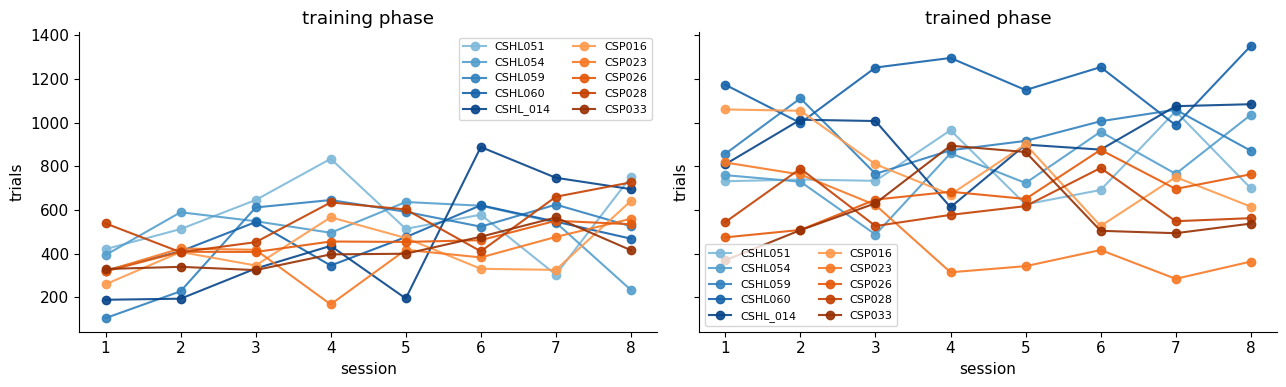

In [4]:
# --- Trials per subject per session, per phase
counts = df.groupby(["phase", "subject_id", "session"]).size().rename("n_trials").reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, phase in zip(axes, ["training", "trained"]):
    for subj, g in counts[counts["phase"] == phase].groupby("subject_id"):
        ax.plot(g["session"], g["n_trials"], "o-", color=MOUSE_COLOR[subj],
                label=subj, alpha=0.9)
    ax.set_title(f"{phase} phase"); ax.set_xlabel("session"); ax.set_ylabel("trials")
    ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 2. Accuracy across signed contrast levels (Psychometric curves)

Empirical **P(response = right)** as a function of **signed contrast**.

**Trained phase**: the mouse is at stable expert performance, so the 8 sessions
can be pooled into one clean psychometric curve per mouse.

**Training phase**: pooling is *not* valid here. During training the IBL
pipeline introduces contrasts progressively (100 % and 50 % first; then 25 %,
12.5 %, 6.25 %, 0 % added over later sessions) *and* the mouse is still learning.
A psychometric pooled over all 8 training sessions therefore mixes a changing
animal with a changing stimulus set, producing a spurious non-monotonic
("U-shaped") curve (the high-contrast bins are diluted by naive early-session
trials while the low-contrast bins exist only in late sessions). So we show the
training psychometric **per session**: each curve is then a clean, well-defined
snapshot. Early sessions (dark) are shallow with few contrasts; later sessions
(light) steepen as the mouse learns and the contrast set grows.

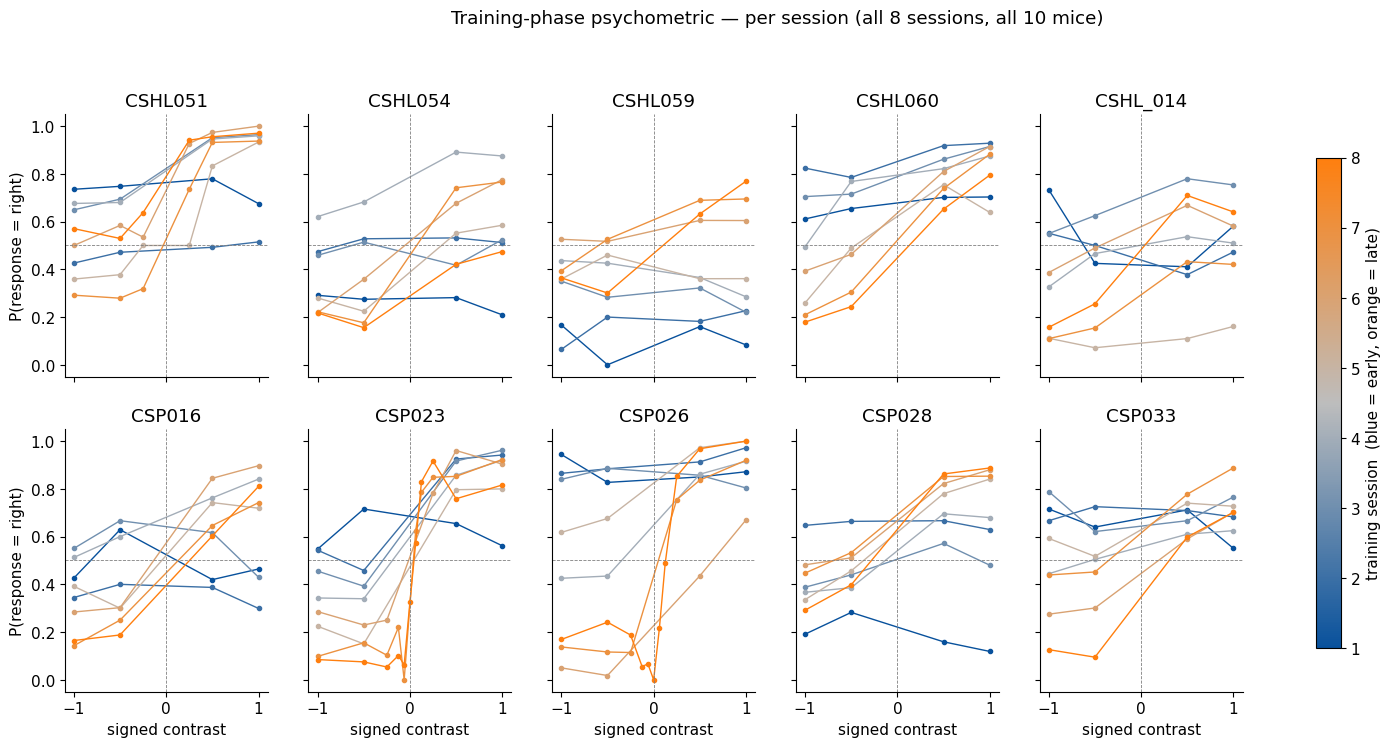

In [5]:
# --- Training psychometric, per session
train = df[(df["phase"] == "training") & df["response"].notna()]
mice = sorted(train["subject_id"].unique())

fig, axes = plt.subplots(2, 5, figsize=(19, 7.5), sharex=True, sharey=True)
for ax, subj in zip(axes.flat, mice):
    g = train[train["subject_id"] == subj]
    for sess, gs in g.groupby("session"):
        psy = gs.groupby("signed_contrast")["response"].mean()
        ax.plot(psy.index, psy.values, "o-", ms=3, lw=1,
                color=SESSION_CMAP((sess - 1) / 7))
    ax.axhline(0.5, color="gray", lw=0.6, ls="--")
    ax.axvline(0.0, color="gray", lw=0.6, ls="--")
    ax.set_title(subj)
for ax in axes[-1]:
    ax.set_xlabel("signed contrast")
for ax in axes[:, 0]:
    ax.set_ylabel("P(response = right)")

sm = plt.cm.ScalarMappable(cmap=SESSION_CMAP, norm=plt.Normalize(1, 8))
fig.colorbar(sm, ax=axes, shrink=0.85,
             label="training session  (blue = early, orange = late)")
fig.suptitle("Training-phase psychometric — per session (all 8 sessions, all 10 mice)",
             y=1.02)
plt.show()

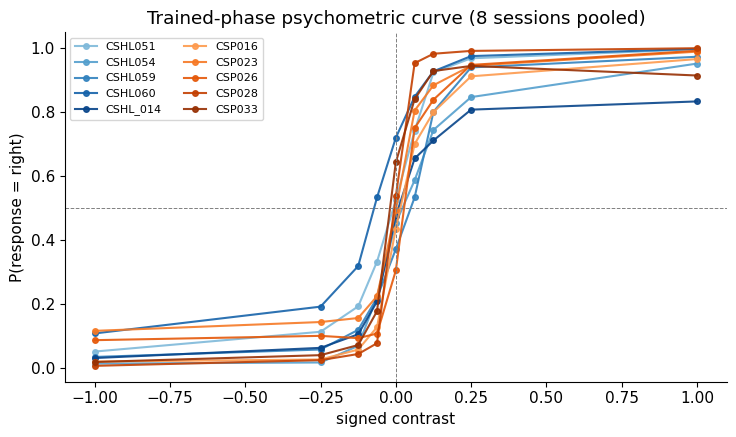

In [6]:
# --- Trained psychometric, pooled across the 8 sessions
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sub = df[(df["phase"] == "trained") & df["response"].notna()]
for subj, g in sub.groupby("subject_id"):
    psy = g.groupby("signed_contrast")["response"].mean()
    ax.plot(psy.index, psy.values, "o-", ms=4, color=MOUSE_COLOR[subj],
            alpha=0.9, label=subj)
ax.axhline(0.5, color="gray", lw=0.7, ls="--")
ax.axvline(0.0, color="gray", lw=0.7, ls="--")
ax.set_title("Trained-phase psychometric curve (8 sessions pooled)")
ax.set_xlabel("signed contrast"); ax.set_ylabel("P(response = right)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 3. Accuracy across sessions (Learning curves)

Mean accuracy per session. Training-phase mice ramp up; trained-phase mice sit
near asymptote.

**Why does the training phase end *below* the trained phase?** The two phases
are **not contiguous**. The 8 "training" sessions are the mouse's *earliest*
`trainingChoiceWorld` sessions (the naive start of learning). The 8 "trained"
sessions are its *earliest* `biasedChoiceWorld` sessions. Between them the mouse
trained for several more weeks (more sessions, intermediate stages) until it
met IBL's proficiency criteria and graduated. That maturation gap is simply not
sampled here (so training-session 8 is *not* the day before trained-session 1).

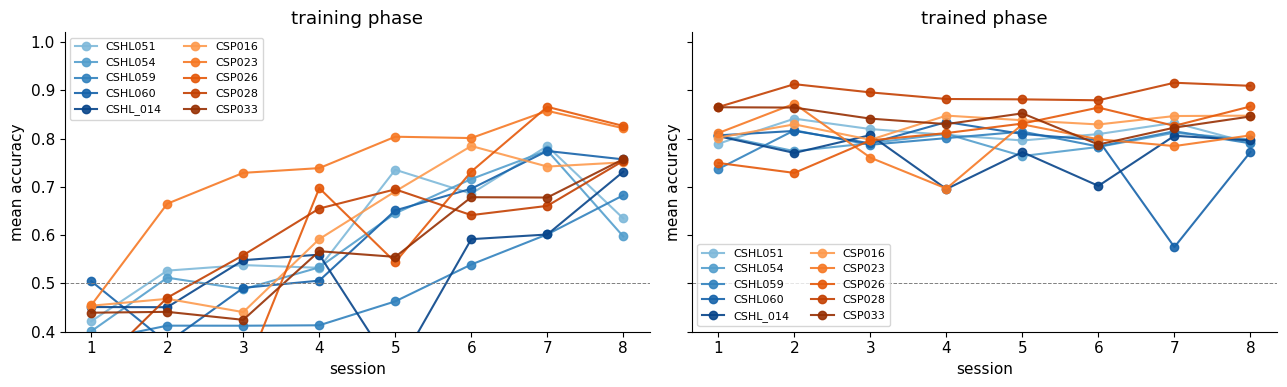

In [7]:
# --- Mean accuracy per session per subject
acc = (df.dropna(subset=["correct"])
         .groupby(["phase", "subject_id", "session"])["correct"].mean().reset_index())
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, phase in zip(axes, ["training", "trained"]):
    for subj, g in acc[acc["phase"] == phase].groupby("subject_id"):
        ax.plot(g["session"], g["correct"], "o-", color=MOUSE_COLOR[subj],
                label=subj, alpha=0.9)
    ax.axhline(0.5, color="gray", lw=0.7, ls="--")
    ax.set_title(f"{phase} phase"); ax.set_xlabel("session"); ax.set_ylabel("mean accuracy")
    ax.set_ylim(0.4, 1.02); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 4. Reaction times — idea of data-cleaning exercise

`reaction_time_s` (first wheel movement − stimulus onset) is shipped uncleaned.
The dashed lines mark IBL's valid analysis window **[0.08, 2.0] s**. Note the
mass of trials at negative / sub-80 ms values (movements that began before or
too soon after stimulus onset to be genuine responses).


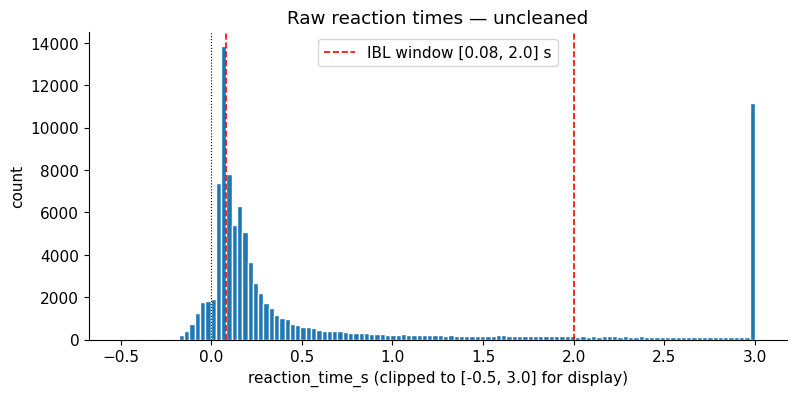

negative reaction_time_s     :   6485  (6.5%)
in IBL window [0.08, 2.0] s  :  55300  (55.3%)
NaN reaction_time_s          :   1542  (1.5%)


In [8]:
# --- Raw reaction-time distribution, with the IBL validity window
rt = df["reaction_time_s"].dropna()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rt.clip(-0.5, 3.0), bins=120, color="C0", edgecolor="white")
ax.axvline(0.08, color="red", lw=1.2, ls="--", label="IBL window [0.08, 2.0] s")
ax.axvline(2.0,  color="red", lw=1.2, ls="--")
ax.axvline(0.0,  color="black", lw=0.8, ls=":")
ax.set_xlabel("reaction_time_s (clipped to [-0.5, 3.0] for display)")
ax.set_ylabel("count"); ax.set_title("Raw reaction times — uncleaned")
ax.legend()
plt.show()

n = len(df)
print(f"negative reaction_time_s     : {(df['reaction_time_s'] < 0).sum():>6}  ({(df['reaction_time_s'] < 0).mean()*100:.1f}%)")
print(f"in IBL window [0.08, 2.0] s  : {((df['reaction_time_s']>=0.08)&(df['reaction_time_s']<=2.0)).sum():>6}  ({((df['reaction_time_s']>=0.08)&(df['reaction_time_s']<=2.0)).mean()*100:.1f}%)")
print(f"NaN reaction_time_s          : {df['reaction_time_s'].isna().sum():>6}  ({df['reaction_time_s'].isna().mean()*100:.1f}%)")


## 5. Reaction time vs response time

`reaction_time_s` = time to *start* moving; `response_time_s` = time to
*complete* the choice. Restricting to the IBL-valid reaction-time window for
this comparison. Cell below is a sanity check.


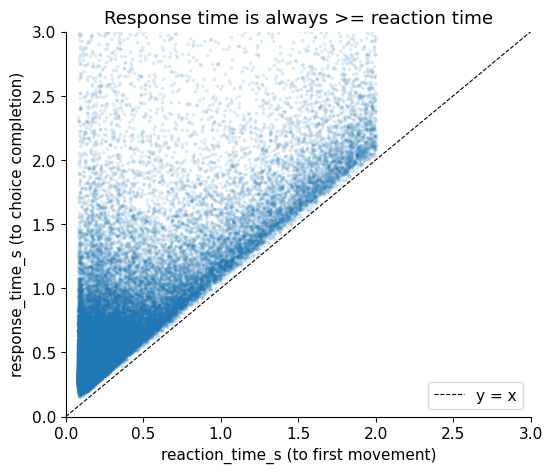

In [9]:
# --- reaction vs response time (valid-RT trials only)
valid = df[(df["reaction_time_s"] >= 0.08) & (df["reaction_time_s"] <= 2.0)]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(valid["reaction_time_s"], valid["response_time_s"], s=3, alpha=0.1, color="C0")
lim = [0, 3]
ax.plot(lim, lim, "k--", lw=0.8, label="y = x")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("reaction_time_s (to first movement)")
ax.set_ylabel("response_time_s (to choice completion)")
ax.set_title("Response time is always >= reaction time")
ax.legend()
plt.show()


## 6. Bias-block effect (trained phase)

In the trained phase, `probability_left` switches between blocks. The block
prior shifts the psychometric curve laterally (strongest at 0% contrast), where
the mouse has no visual evidence and must rely on the prior (the prior is 
learned by the mice over time experiencing alternation of blocks biased on 
one side or the other). This could be a natural place where to plug some 
statistical testing.


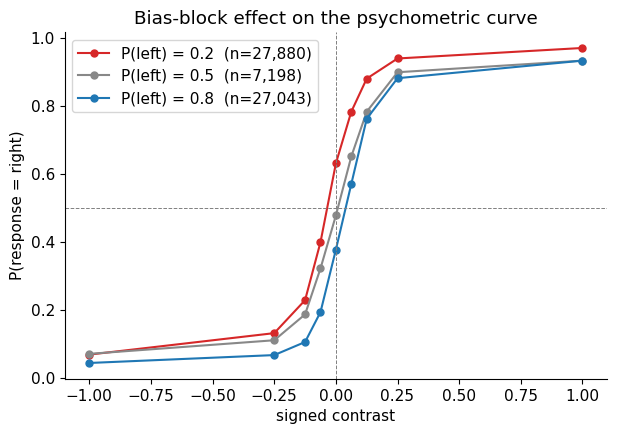

In [10]:
# --- Psychometric curve split by probability_left (trained phase)
trained = df[(df["phase"] == "trained") & df["response"].notna()].copy()
trained["pL"] = trained["probability_left"].round(2)
fig, ax = plt.subplots(figsize=(7, 4.5))
colours = {0.2: "#d62728", 0.5: "#888888", 0.8: "#1f77b4"}
for pL, color in colours.items():
    sub = trained[trained["pL"] == pL]
    if sub.empty:
        continue
    psy = sub.groupby("signed_contrast")["response"].mean()
    ax.plot(psy.index, psy.values, "o-", ms=5, color=color,
            label=f"P(left) = {pL}  (n={len(sub):,})")
ax.axhline(0.5, color="gray", lw=0.7, ls="--")
ax.axvline(0.0, color="gray", lw=0.7, ls="--")
ax.set_xlabel("signed contrast"); ax.set_ylabel("P(response = right)")
ax.set_title("Bias-block effect on the psychometric curve")
ax.legend()
plt.show()


## 7. No-go trials

No-go trials (`no_go = True`) are kept and flagged. They are rare for engaged
mice. Second data-cleaning exercise: students decide how to handle them.


In [11]:
# --- No-go counts
print("no-go trials total:", int(df["no_go"].sum()), f"({df['no_go'].mean()*100:.2f}%)")
print()
print("no-go rate per phase:")
print((df.groupby("phase")["no_go"].mean() * 100).round(2).astype(str) + " %")
print()
print("no-go count per subject:")
print(df[df["no_go"]].groupby("subject_id").size().sort_values(ascending=False).to_dict())


no-go trials total: 310 (0.31%)

no-go rate per phase:
phase
trained     0.25 %
training    0.41 %
Name: no_go, dtype: str

no-go count per subject:
{'CSHL051': 73, 'CSP023': 51, 'CSP016': 49, 'CSHL054': 34, 'CSP028': 31, 'CSHL_014': 27, 'CSHL059': 25, 'CSP033': 15, 'CSHL060': 5}


## 8. Block-prior effect at zero contrast (trained phase)

On 0 %-contrast trials there is no visual evidence, so **P(response = right)** is
driven purely by the mouse's expectation. In the **trained** phase that
expectation is set by the **block prior**, so we split the zero-contrast trials
by block: left-biased (`probability_left` = 0.8) vs right-biased
(`probability_left` = 0.2). Every mouse chooses "right" more often in
right-biased blocks — a consistent within-subject effect, and a clean
illustration of prior use.

(We do *not* split the training phase: there `probability_left` is fixed at 0.5,
so there are no blocks. Note also that 0 %-contrast trials still have a defined
`correct` side — set by the block prior — so they are not "undefined" trials.)

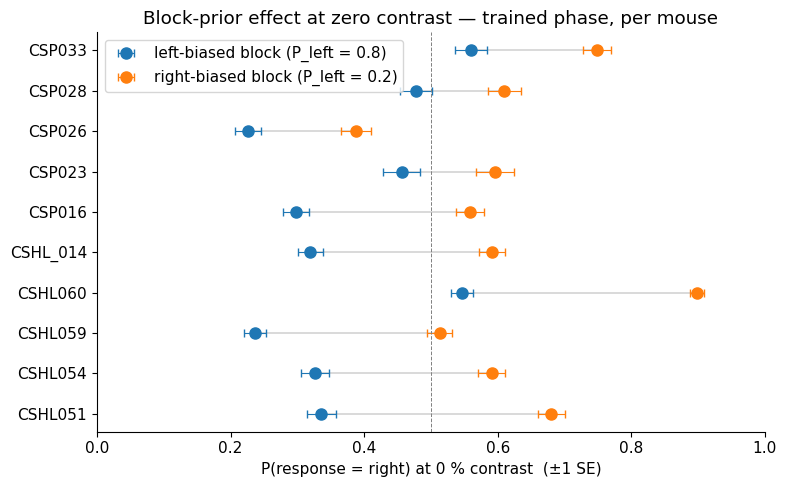

   subject_id  probability_left   p_right    n        se
0     CSHL051               0.2  0.680147  544  0.019998
1     CSHL051               0.8  0.336000  500  0.021124
2     CSHL054               0.2  0.590835  611  0.019891
3     CSHL054               0.8  0.326415  530  0.020368
4     CSHL059               0.2  0.512925  735  0.018437
5     CSHL059               0.8  0.236307  639  0.016805
6     CSHL060               0.2  0.897936  872  0.010252
7     CSHL060               0.8  0.546498  871  0.016868
8    CSHL_014               0.2  0.591615  644  0.019369
9    CSHL_014               0.8  0.319218  614  0.018813
10     CSP016               0.2  0.558182  550  0.021175
11     CSP016               0.8  0.297535  568  0.019183
12     CSP023               0.2  0.595318  299  0.028385
13     CSP023               0.8  0.455927  329  0.027459
14     CSP026               0.2  0.387580  467  0.022545
15     CSP026               0.8  0.225873  487  0.018948
16     CSP028               0.2

In [12]:
# --- P(response = right) at zero contrast, split by block (TRAINED phase, per mouse)
zc = df[(df["phase"] == "trained") & (df["signed_contrast"] == 0) & df["response"].notna()]
blocks = {0.8: ("left-biased block (P_left = 0.8)",  "#1f77b4"),
          0.2: ("right-biased block (P_left = 0.2)", "#ff7f0e")}
bias = (zc[zc["probability_left"].isin(blocks)]
        .groupby(["subject_id", "probability_left"])
        .agg(p_right=("response", "mean"), n=("response", "size")).reset_index())
bias["se"] = np.sqrt(bias["p_right"] * (1 - bias["p_right"]) / bias["n"])

mice = sorted(bias["subject_id"].unique())
y = {m: i for i, m in enumerate(mice)}
fig, ax = plt.subplots(figsize=(8, 5))
for m in mice:
    g = bias[bias["subject_id"] == m]
    ax.plot(g["p_right"], [y[m]] * len(g), "-", color="lightgray", lw=1.2, zorder=1)
for pL, (label, color) in blocks.items():
    g = bias[bias["probability_left"] == pL]
    ax.errorbar(g["p_right"], [y[m] for m in g["subject_id"]], xerr=g["se"],
                fmt="o", color=color, ms=8, capsize=3, lw=0.8, label=label, zorder=2)
ax.axvline(0.5, color="gray", lw=0.7, ls="--")
ax.set_yticks(range(len(mice))); ax.set_yticklabels(mice)
ax.set_xlabel("P(response = right) at 0 % contrast  (±1 SE)")
ax.set_xlim(0, 1)
ax.set_title("Block-prior effect at zero contrast — trained phase, per mouse")
ax.legend()
plt.tight_layout(); plt.show()
print(bias)

## Notes for designing Notebooks 3–8

- **NB3 (descriptive stats)**: reaction-time distributions are a perfect
  mean-vs-median / skew / log-transform example; *and* `reaction_time_s` doubles
  as a data-cleaning exercise (negative + out-of-range values, IBL window).
- **NB4 (t-tests)**: citable real result: trained mice score significantly
  above 50 % chance on 0 %-contrast trials (one-sample t-test).
- **NB5 (ANOVA / RM-ANOVA)**: `probability_left` is a genuine 3-level
  within-subject factor in the trained phase.
- **NB6-8 (non-parametrics, regression, mixed-effects)**: skewed RTs motivate
  rank tests / bootstrap; psychometric & chronometric curves motivate
  regression.

Dataset "messiness" to teach with: **raw reaction times**
(§4) and **no-go trials** (§7).
